In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Most-Recent-Cohorts-Institution.csv")

df.head()

/var/folders/__/9rckbb79601d4phm0yww6lpc0000gn/T/ipykernel_34902/4262360988.py:1: DtypeWarning: Columns (0: NPCURL, 1: INC_PCT_LO, 2: DEP_STAT_PCT_IND, 3: DEP_INC_AVG, 4: IND_INC_AVG, 5: CUML_DEBT_N, 6: INC_N, 7: DEP_INC_N, 8: IND_INC_N, 9: DEP_STAT_N, 10: APPL_SCH_N, 11: SEPAR_DT_N, 12: RPY_7YR_N, 13: FIRSTGEN_RPY_7YR_N, 14: NOTFIRSTGEN_RPY_7YR_N, 15: AGE_ENTRY, 16: AGEGE24, 17: DEPENDENT, 18: FAMINC, 19: MD_FAMINC, 20: FAMINC_IND, 21: PCT_WHITE, 22: PCT_BLACK, 23: PCT_ASIAN, 24: PCT_HISPANIC, 25: PCT_BA, 26: PCT_GRAD_PROF, 27: PCT_BORN_US, 28: MEDIAN_HH_INC, 29: POVERTY_RATE, 30: UNEMP_RATE, 31: LN_MEDIAN_HH_INC, 32: GT_25K_P10, 33: GT_25K_P6, 34: MN_EARN_WNE_P7, 35: GT_25K_P7, 36: PCT10_EARN_WNE_P8, 37: PCT90_EARN_WNE_P8, 38: GT_25K_P8, 39: C150_L4_POOLED_SUPP, 40: C150_4_POOLED_SUPP, 41: C200_L4_POOLED_SUPP, 42: C200_4_POOLED_SUPP, 43: ALIAS, 44: T4APPROVALDATE, 45: RET_FT4_POOLED_SUPP, 46: RET_FTL4_POOLED_SUPP, 47: RET_PT4_POOLED_SUPP, 48: RET_PTL4_POOLED_SUPP, 49: TRANS_4_POOLED_

,UNITID,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,...,COUNT_WNE_MALE1_P11,GT_THRESHOLD_P11,MD_EARN_WNE_INC1_P11,MD_EARN_WNE_INC2_P11,MD_EARN_WNE_INC3_P11,MD_EARN_WNE_INDEP0_P11,MD_EARN_WNE_INDEP1_P11,MD_EARN_WNE_MALE0_P11,MD_EARN_WNE_MALE1_P11,SCORECARD_SECTOR
0,100654,100200.0,1002.0,Alabama A & M University,Normal,AL,35762,Southern Association of Colleges and Schools C...,www.aamu.edu/,www.aamu.edu/admissions-aid/tuition-fees/net-p...,...,777.0,0.6250,36650.0,41070.0,47016.0,38892.0,41738.0,38167.0,40250.0,4
1,100663,105200.0,1052.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,Southern Association of Colleges and Schools C...,https://www.uab.edu/,https://tcc.ruffalonl.com/University of Alabam...,...,1157.0,0.7588,47182.0,51896.0,54368.0,50488.0,51505.0,46559.0,59181.0,4
2,100690,2503400.0,25034.0,Amridge University,Montgomery,AL,36117-3553,Southern Association of Colleges and Schools C...,https://www.amridgeuniversity.edu/,https://www2.amridgeuniversity.edu:9091/,...,67.0,0.5986,35752.0,41007.0,NaN,NaN,38467.0,32654.0,49435.0,5
3,100706,105500.0,1055.0,University of Alabama in Huntsville,Huntsville,AL,35899,Southern Association of Colleges and Schools C...,www.uah.edu/,uah.clearcostcalculator.com/student/default/ne...,...,802.0,0.7810,51208.0,62219.0,62577.0,55920.0,60221.0,47787.0,67454.0,4
4,100724,100500.0,1005.0,Alabama State University,Montgomery,AL,36104-0271,Southern Association of Colleges and Schools C...,www.alasu.edu/,tcc.ruffalonl.com/Alabama State University/Fre...,...,1049.0,0.5378,32844.0,36932.0,37966.0,34294.0,31797.0,32303.0,36964.0,4


In [3]:
df = df[[
    "REGION",
    "SAT_AVG",
    "ADM_RATE",
    "UGDS",
    "MD_FAMINC"
]]

df.head()

,REGION,SAT_AVG,ADM_RATE,UGDS,MD_FAMINC
0,5,947.0,0.6622,5726.0,23553
1,5,1251.0,0.8842,12118.0,34489
2,5,NaN,NaN,226.0,15033.5
3,5,1321.0,0.7425,6650.0,44787
4,5,977.0,0.9564,3322.0,22080.5


In [4]:
df = df.dropna()

df.shape

(1062, 5)

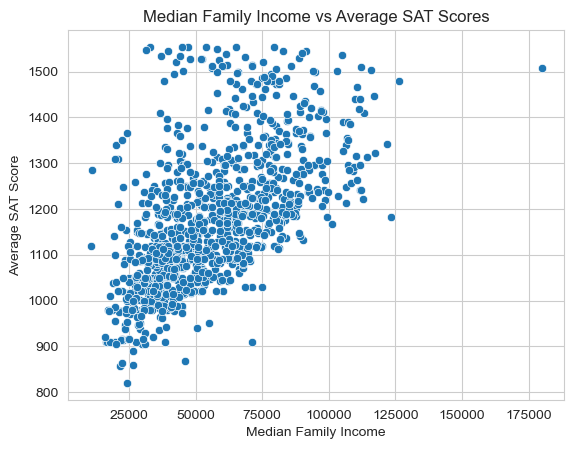

In [7]:
sns.scatterplot(x="MD_FAMINC", y="SAT_AVG", data=df)

plt.title("Median Family Income vs Average SAT Scores")

plt.xlabel("Median Family Income")

plt.ylabel("Average SAT Score")

plt.show()

In [6]:
df["MD_FAMINC"] = pd.to_numeric(df["MD_FAMINC"], errors="coerce")
df["SAT_AVG"] = pd.to_numeric(df["SAT_AVG"], errors="coerce")

df = df.dropna()

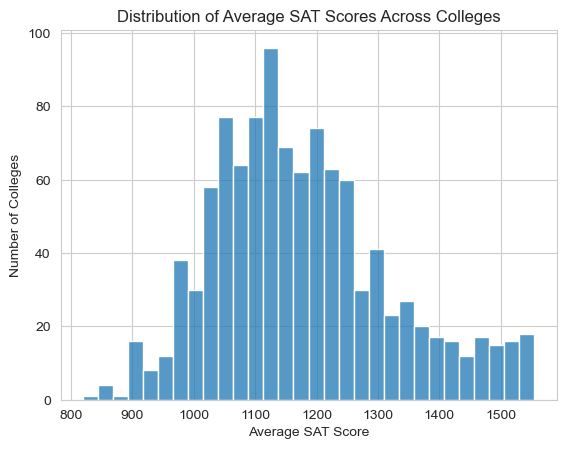

In [8]:
sns.histplot(df["SAT_AVG"], bins=30)

plt.title("Distribution of Average SAT Scores Across Colleges")

plt.xlabel("Average SAT Score")

plt.ylabel("Number of Colleges")

plt.show()

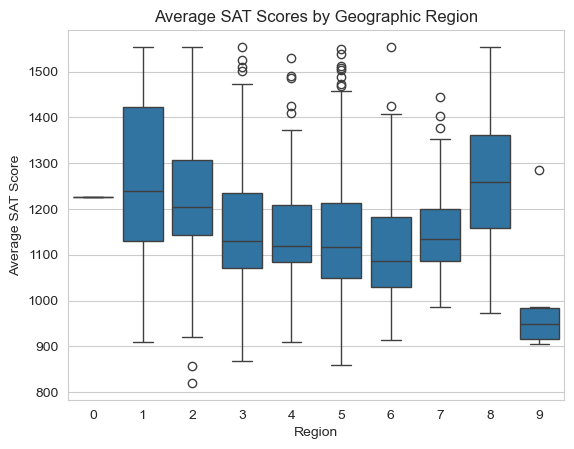

In [9]:
sns.boxplot(x="REGION", y="SAT_AVG", data=df)

plt.title("Average SAT Scores by Geographic Region")

plt.xlabel("Region")

plt.ylabel("Average SAT Score")

plt.show()

In [11]:
from sklearn.linear_model import LinearRegression

X = df[["MD_FAMINC"]]
y = df["SAT_AVG"]

model = LinearRegression()

model.fit(X, y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [0.00381917]
Intercept: 963.0955867325923


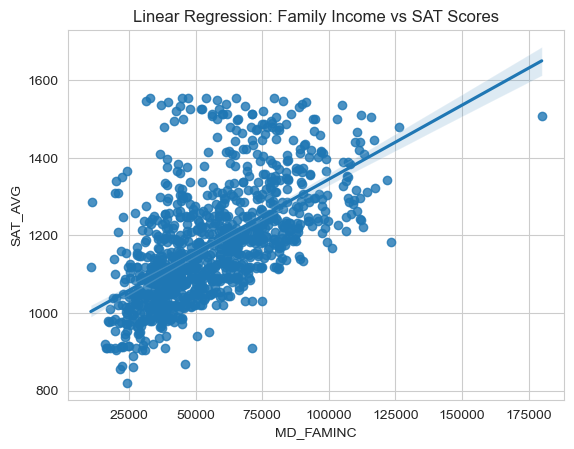

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='MD_FAMINC', y='SAT_AVG', data=df)
plt.title("Linear Regression: Family Income vs SAT Scores")
plt.show()